In [1]:
## importing some libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# loading the dataset
df = pd.read_csv('../data/height_weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,150
1,47,152
2,50,155
3,52,158
4,54,160


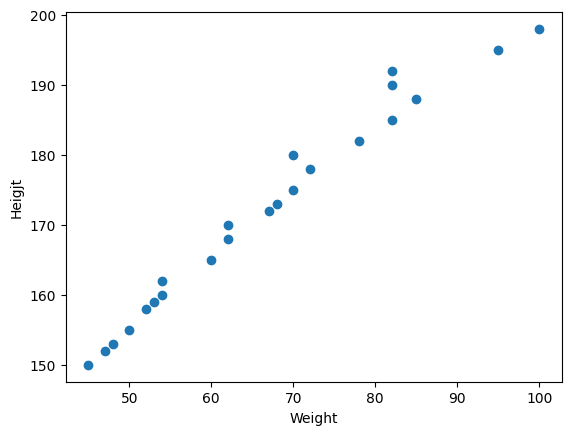

In [4]:
# scatter plot to see the relation
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Heigjt')
plt.show()

In [5]:
# finding the correlation
df.corr()

,Weight,Height
Weight,1.000000,0.986062
Height,0.986062,1.000000


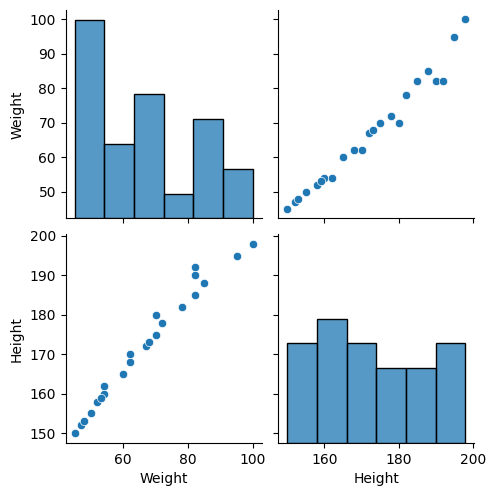

In [6]:
## another visualisation
# pairplot for corelation
import seaborn as sns
sns.pairplot(df)

In [7]:
# dividing the featues 
# Independent and Dependent features
X = df[['Weight']]   # Independent Features must be a dataframe or 2-d array
y = df['Height']     # this musy be a Pandas Series or 1-d array

In [8]:
# splitting the data
# Train Test Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.25,
                                                    random_state=42)

In [10]:
## Standardlisation
# Standardscalar
''' 
    Apllying z score internally
    for mean=0, std=1
'''
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [11]:
# Apply sSmple Linear Regression
from sklearn.linear_model import LinearRegression

In [12]:
regression = LinearRegression(n_jobs=-1)

In [13]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [14]:
''' 
   -  Coefficient: One unit movement in X-axis lead to how much movement of y
   -  Intercept: at what point our line meets the Y-axis when X is ZERO
'''
print('Coefficient or slope', regression.coef_)
print('Intercept', regression.intercept_)

Coefficient or slope [14.34566288]
Intercept 171.05882352941177


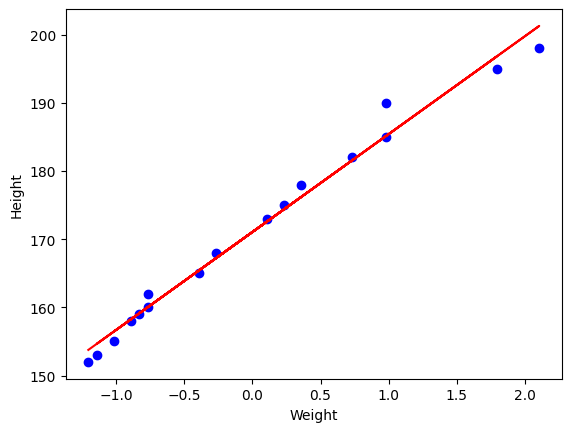

In [15]:
## plot best fit line wrt train data
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, regression.predict(X_train), color='red')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()  

### Prediction for the test data
1. predicted height output  = intercept_ + coeff_*(weights)
2. y_pred_test = 171.058 + 14.345(X_test)

In [16]:
y_pred =regression.predict(X_test)
y_pred

array([187.82764491, 171.69160924, 151.96978787, 167.20937711,
       185.13830563, 174.38094852])

In [17]:
## performance metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [18]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print('Mean Squared Error', mse)
print('Root Mean Squared Error', rmse)
print('Mean Absolute Error', mae)
print('R-squared', score)

Mean Squared Error 15.074840096513265
Root Mean Squared Error 3.882633139573357
Mean Absolute Error 2.9536504076025807
R-squared 0.9207514247262737


## OLS Linear regression

In [19]:
import statsmodels.api as sm

sm.OLS(y_train, X_train).fit()

class statsmodels.regression.linear_model.OLS(endog, 
                                                    exog=None, 
                                                    missing='none', 
                                                    hasconst=None, 
                                                    **kwargs)


'''
* endogarray_like
    A 1-d endogenous response variable. The dependent variable.

* exogarray_like
    A nobs x k array where nobs is the number of observations and k is the number of regressors. 
An intercept is not included by default and should be added by the user. 

 OLS (Ordinary Least Squares) Regression and Linear Regression, it's important to clarify that OLS is actually a method for estimating the parameters of a linear regression model. In other words, linear regression is the model, and OLS is the most common technique used to fit that model to the data.
'''

In [20]:
model = sm.OLS(y_train, X_train).fit()

In [21]:
prediction = model.predict(X_test)
prediction

array([ 16.76882138,   0.63278571, -19.08903566,  -3.84944642,
        14.0794821 ,   3.32212499])

In [22]:
model.summary()

/Users/spy/Desktop/ml-journey/venv/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.007
Model:                            OLS   Adj. R-squared (uncentered):             -0.055
Method:                 Least Squares   F-statistic:                             0.1125
Date:                Sat, 09 May 2026   Prob (F-statistic):                       0.742
Time:                        02:03:24   Log-Likelihood:                         -111.54
No. Observations:                  17   AIC:                                      225.1
Df Residuals:                      16   BIC:                                      225.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            14.3457     42.767      0.335      0.742     -76.316     105.008
==============================================================================
Omnibus:                        5.392   Durbin-Watson:                   0.000
Prob(Omnibus):                  0.067   Jarque-Bera (JB):                2.740
Skew:                           0.775   Prob(JB):                        0.254
Kurtosis:                       4.210   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## prediction for new data

In [23]:
regression.predict(scalar.transform([[72]]))

/Users/spy/Desktop/ml-journey/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([176.17384137])